# 📊 Advanced Analytics (Python)

This notebook performs advanced analysis including:
- Pareto Analysis
- Cohort Analysis
- Customer Behavior Insights

### 📂 Data Source
Cleaned datasets from Olist E-commerce dataset

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [119]:
orders = pd.read_csv('../data/cleaned/orders.csv')
order_items = pd.read_csv('../data/cleaned/order_items.csv')
products = pd.read_csv('../data/cleaned/products.csv')
customers = pd.read_csv('../data/cleaned/customers.csv')


In [120]:
sales_df = (
    order_items
    .merge(orders, on='order_id', how='inner')
    .merge(products, on='product_id', how='left')
    .merge(customers, on='customer_id', how='left')
).copy()
sales_df = sales_df[sales_df['order_status'] == 'delivered']


In [121]:
sales_df.groupby('customer_id')['order_id'].nunique().value_counts()

order_id
1    96478
Name: count, dtype: int64

In [122]:
product_revenue = (
    sales_df.groupby('product_id')['price']
      .sum()
      .sort_values(ascending=False)
)


In [123]:
cumulative_revenue = product_revenue.cumsum() / product_revenue.sum()


## 🔹 Pareto Analysis (Revenue Contribution)

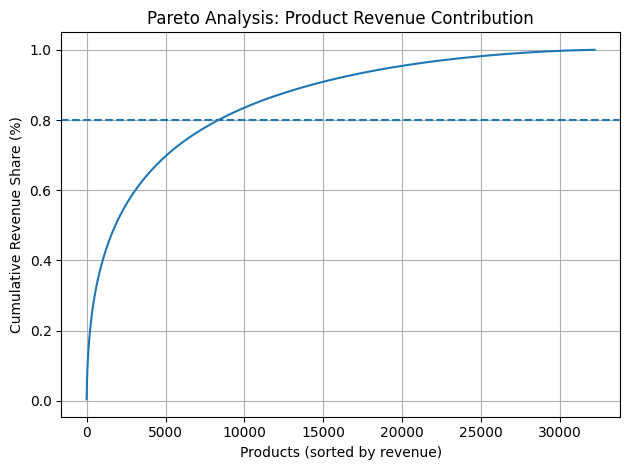

In [124]:
plt.figure()
plt.plot(cumulative_revenue.values)
plt.axhline(0.8, linestyle='--')
plt.title('Pareto Analysis: Product Revenue Contribution')
plt.xlabel('Products (sorted by revenue)')
plt.ylabel('Cumulative Revenue Share (%)')
plt.grid(True)
plt.tight_layout()
plt.show()


### 📌 Insight:
- Top products contribute majority of revenue (Pareto principle observed)
- Revenue is highly concentrated

### 💡 Business Impact:
- Focus marketing on top-performing products

## 🔹 Cohort Analysis (Customer Retention)

In [125]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)


In [126]:
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

orders['cohort_month'] = (
    orders.groupby('customer_id')['order_purchase_timestamp']
          .transform('min')
          .dt.to_period('M')
)

sales_df = sales_df.merge(
    orders[['order_id', 'order_month', 'cohort_month']],
    on='order_id',
    how='left'
)

def cohort_index(df):
    return (
        (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12 +
        (df['order_month'].dt.month - df['cohort_month'].dt.month) + 1
    )

sales_df['order_month'] = sales_df['order_month'].dt.to_timestamp()
sales_df['cohort_month'] = sales_df['cohort_month'].dt.to_timestamp()

sales_df['cohort_index'] = cohort_index(sales_df)


In [127]:
sales_df['cohort_month'] = sales_df['cohort_month'].dt.strftime('%Y-%m')

cohort_data = (
    sales_df.groupby(['cohort_month', 'cohort_index'])['customer_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_id'
)

cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

retention


cohort_index,1
cohort_month,
2016-09,1.0
2016-10,1.0
2016-12,1.0
2017-01,1.0
2017-02,1.0
2017-03,1.0
2017-04,1.0
2017-05,1.0
2017-06,1.0


⚠️ Note:
Due to low repeat purchases in dataset. 
Customer retention analysis shows near-zero repeat purchases.
Most customers transact only once, indicating a low retention business model.

The dataset suggests a marketplace-driven acquisition model rather than
customer loyalty-based growth.
This does not reflect real customer retention behavior.

### 📌 Insight:
- Customers are mostly one-time buyers
- No repeat purchase behavior observed
- Retention appears constant due to lack of repeat transactions

### 💡 Business Impact:
- Need strategies to improve customer retention
- Focus on loyalty programs / re-engagement

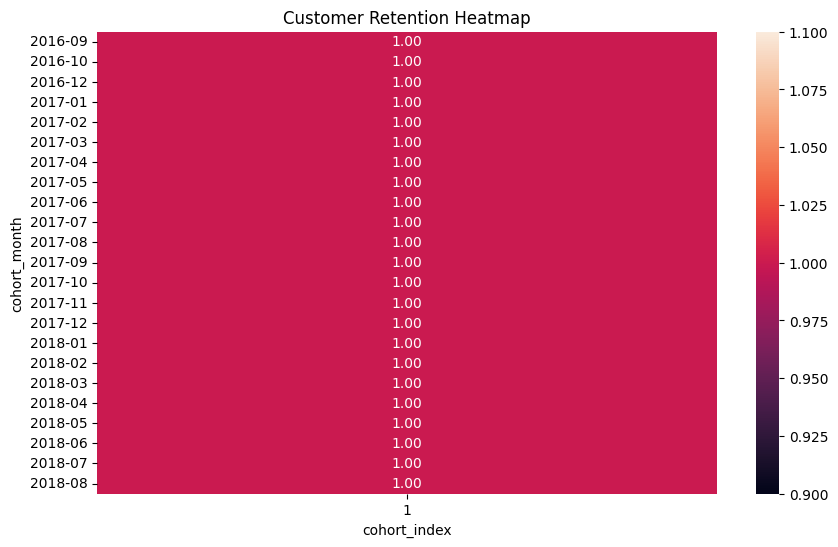

In [128]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(retention, annot=True, fmt=".2f")
plt.title("Customer Retention Heatmap")
plt.show()

## 📈 Final Insights

- Revenue follows Pareto distribution
- Majority customers are one-time buyers
- Customer retention is extremely low
- Business depends heavily on acquisition over retention